# Process one event

In [1]:
from podio.root_io import Reader
import numpy as np
import pandas as pd
from RecoUtils import decodeRawHits, vec3d2mat
from Hit3DBuilder import buildHitPairs
from RecoUtils import CellIDLayerMapper, TimeZMapper
from datar.all import tibble, mutate, if_else, f
from plotnine.ggplot import ggplot
from plotnine import aes, facet_wrap, geom_point


compton_event_path = "./compton_digi.root"
reader = Reader(compton_event_path)

events = reader.get("events")

event = events[0]

Module libc not found.


Welcome to JupyROOT 6.28/06


/opt/podio/v00-17-02/python/podio/EventStore.py:4: FutureWarning: The EventStore based I/O model is deprecated and will be removed. Switch to the Frame based model.
  warnings.warn("The EventStore based I/O model is deprecated and will be removed. Switch to the Frame based model.",


Event has the following collections:
1. TpcSimHits
2. TpcSegHits
3. TpcHits
4. PrimaryParticles
5. TpcWaveformHits
6. TpcDriftHits
7. CaloHits

We need to deal with TpcDriftHits, TpcSegHits, TpcHits, WaveformHits and use TpcSimHits as reference.

## Drift Hits

Drift hit collection is a edm4hep::SimTrackerHitCollection. It has the following members:
- cellID: uint64_t  
- EDep: float       
- time: float       
- pathLength: float 
- position: edm4hep::Vector3d 
- momentum: edm4hep::Vector3f 

Cell ID and layer of DriftHits are meaningless.

In [2]:
drift_hits = event.get("TpcDriftHits") 
print(f"Number of drift hits: {drift_hits.size()}")

Number of drift hits: 1002


In [3]:
from RecoUtils import vec3d2mat

drift_pos = vec3d2mat(drift_hits.position())
drift_time = np.array(drift_hits.time())
drift_edep = np.array(drift_hits.EDep())
drift_cell = np.array(drift_hits.cellID())

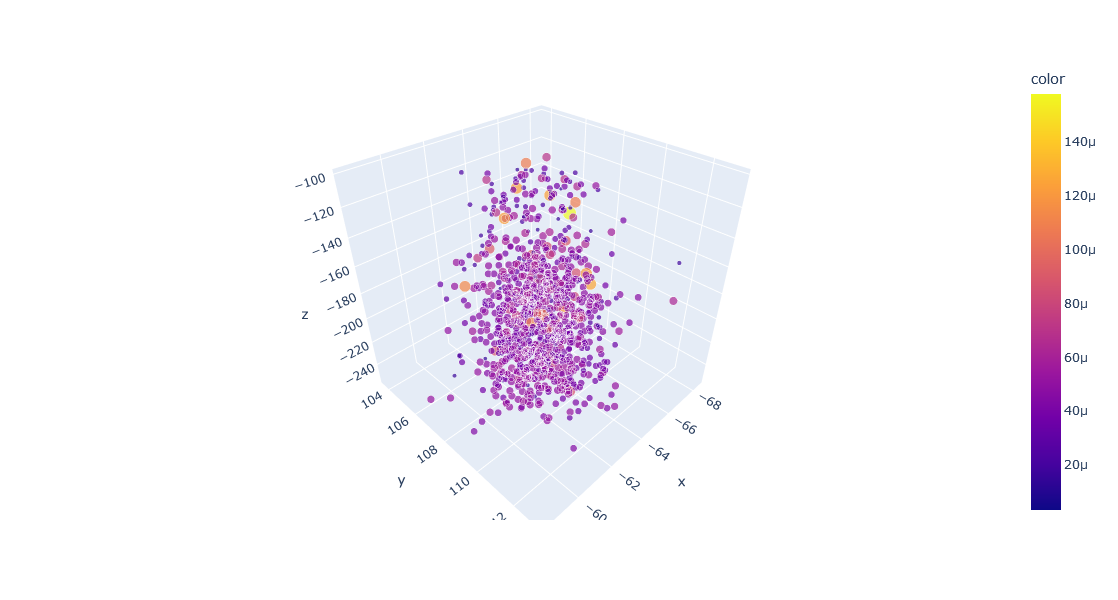

In [4]:
import plotly.express as px

time2z = TimeZMapper()

fig = px.scatter_3d(
    x=drift_pos[:, 0],
    y=drift_pos[:, 1],
    z=time2z(drift_time, drift_pos[:, 2]),
    size=drift_edep,
    color= drift_edep,
    width=900,
    height=600
)
fig.show()

## Segmentation Hits

Segmentation hits is of edm4hep::TrackerHitCollection. It has the following members:
- cellID: uint64_t 
- time: float                
- eDep: float                 
- eDepError: float            
- position: edm4hep::Vector3d 


In [5]:
cell2layer = CellIDLayerMapper()

seg_hits = event.get("TpcSegHits")

seg_pos = vec3d2mat(seg_hits.position())
seg_time = np.array(seg_hits.time())
seg_edep = np.array(seg_hits.eDep())
seg_cell = np.array(seg_hits.cellID())
seg_layer = cell2layer(seg_cell)

Info in <TGeoManager>: Changing system of units to Geant4 units (mm, ns, MeV).


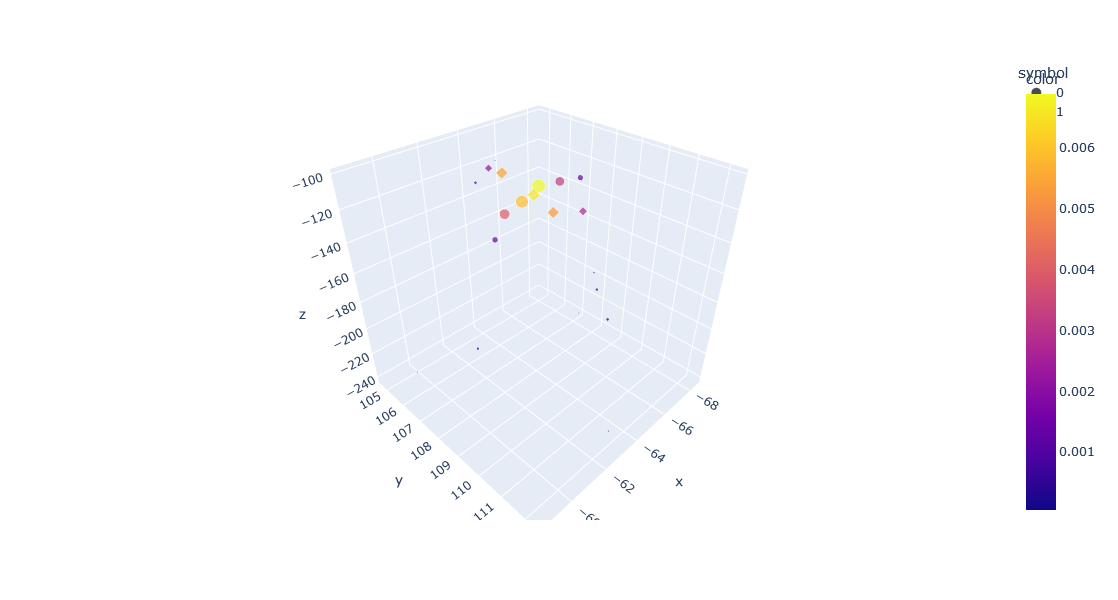

In [6]:
fig = px.scatter_3d(
    x=seg_pos[:, 0],
    y=seg_pos[:, 1],
    z=time2z(seg_time, seg_pos[:, 2]),
    color=seg_edep,
    size=seg_edep,
    symbol=seg_layer,
    width=900,
    height=600,
)
fig.show()

/data/home/lixp/anaconda3/envs/pyroot/lib/python3.10/site-packages/plotnine/utils.py:289: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/data/home/lixp/anaconda3/envs/pyroot/lib/python3.10/site-packages/plotnine/utils.py:596: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/data/home/lixp/anaconda3/envs/pyroot/lib/python3.10/site-packages/plotnine/geoms/geom.py:289: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



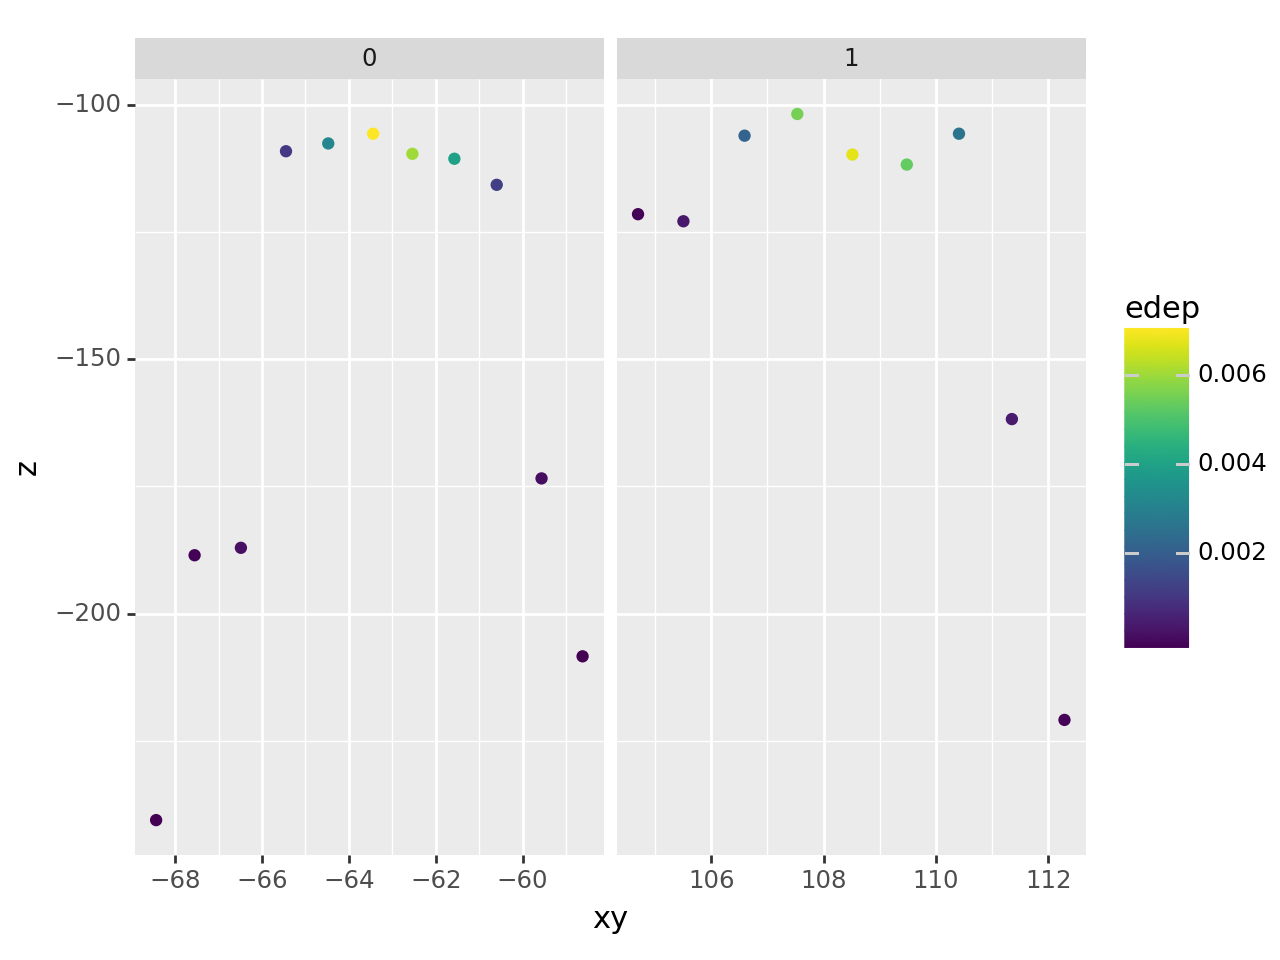

<Figure Size: (640 x 480)>

In [7]:
(
    tibble(
        x=seg_pos[:, 0],
        y=seg_pos[:, 1],
        z=time2z(seg_time, seg_pos[:, 2]),
        layer=seg_layer,
        edep=seg_edep,
        xy=if_else(f.layer == 0, f.x, f.y),
    )
    >> ggplot(aes(x="xy", y="z", color="edep")) # type: ignore
    + geom_point()
    + facet_wrap("~layer", scales="free_x")  # type: ignore
)

## Tpc Hits

Tpc hits is of edm4hep::TrackerHitCollection. It has the following members:
- cellID: uint64_t 
- time: float                
- eDep: float                 
- eDepError: float            
- position: edm4hep::Vector3d 

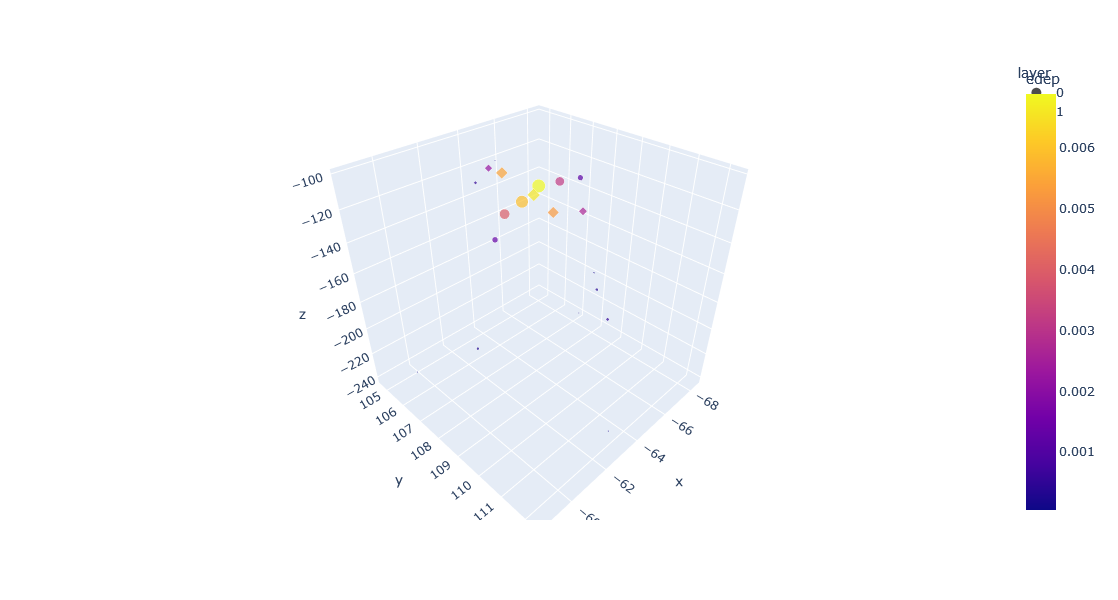

/data/home/lixp/anaconda3/envs/pyroot/lib/python3.10/site-packages/plotnine/utils.py:289: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/data/home/lixp/anaconda3/envs/pyroot/lib/python3.10/site-packages/plotnine/utils.py:596: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/data/home/lixp/anaconda3/envs/pyroot/lib/python3.10/site-packages/plotnine/geoms/geom.py:289: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



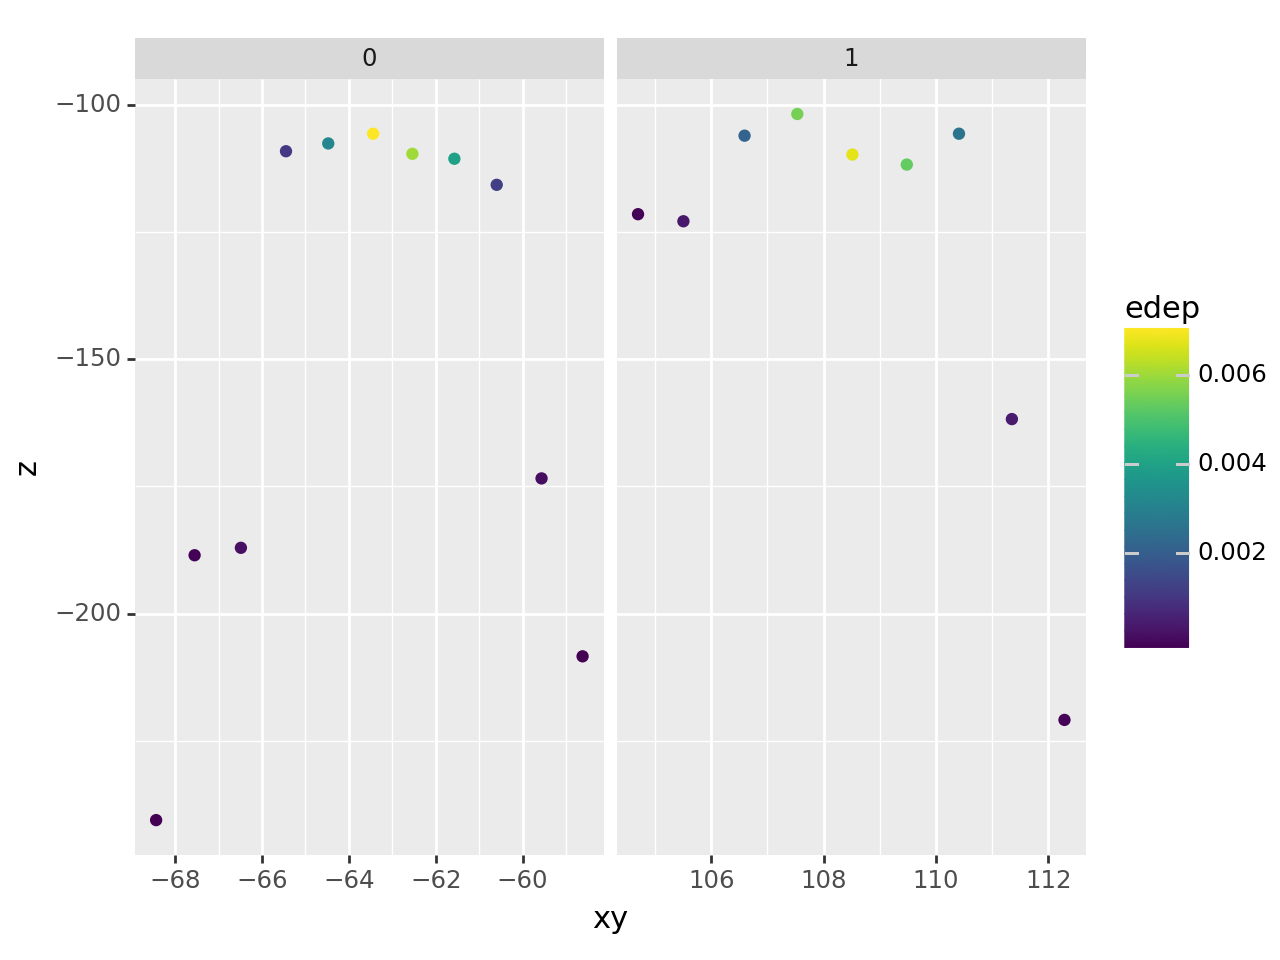

<Figure Size: (640 x 480)>

In [8]:
smear_hits = event.get("TpcHits")

smear_pos = vec3d2mat(seg_hits.position())
smear_time = np.array(seg_hits.time())
smear_edep = np.array(seg_hits.eDep())
smear_cell = np.array(seg_hits.cellID())
smear_layer = cell2layer(seg_cell)

df_smear = tibble(
    x=smear_pos[:, 0],
    y=smear_pos[:, 1],
    z=time2z(smear_time, smear_pos[:, 2]),
    layer=smear_layer,
    edep=smear_edep,
    xy=if_else(f.layer == 0, f.x, f.y),
)

fig = px.scatter_3d(
    df_smear,
    x="x",
    y="y",
    z="z",
    color="edep",
    size="edep",
    symbol="layer",
    width=900,
    height=600,
)
fig.show()

(
    df_smear
    >> ggplot(aes(x="xy", y="z", color="edep"))  # type: ignore
    + geom_point()
    + facet_wrap("~layer", scales="free_x")  # type: ignore
)

## Plot together

In [9]:
from datar.all import bind_rows, select, filter_, c

df_drift = tibble(
    x=drift_pos[:, 0],
    y=drift_pos[:, 1],
    z=time2z(drift_time, drift_pos[:, 2]),
    edep=drift_edep,
    log_edep_7=7 + np.log10(drift_edep),
    Type="Drift Hits",
)
df_seg = tibble(
    x=seg_pos[:, 0],
    y=seg_pos[:, 1],
    z=time2z(seg_time, seg_pos[:, 2]),
    layer=seg_layer,
    edep=seg_edep,
    log_edep_7=7 + np.log10(seg_edep),
    Type="Segmentation Hits",
)
df_smear = tibble(
    x=smear_pos[:, 0],
    y=smear_pos[:, 1],
    z=time2z(smear_time, smear_pos[:, 2]),
    layer=smear_layer,
    edep=smear_edep,
    log_edep_7=7 + np.log10(seg_edep),
    Type="Smeared Hits",
)

df_3d = bind_rows(df_drift, select(df_seg, ~c(f.layer)), select(df_smear, ~c(f.layer)))

df_xz = bind_rows(
    df_drift,
    df_seg >> filter_(f.layer == 0) >> select(~c(f.layer)),
    df_smear >> filter_(f.layer == 0) >> select(~c(f.layer)),
)

df_yz = bind_rows(
    df_drift,
    df_seg >> filter_(f.layer != 0) >> select(~c(f.layer)),
    df_smear >> filter_(f.layer != 0) >> select(~c(f.layer)),
)

df_2d = bind_rows(
    df_drift >> mutate(xy=f.x, layer=0),  # type: ignore
    df_drift >> mutate(xy=f.y, layer=1),  # type: ignore
    df_seg >> mutate(xy=if_else(f.layer == 0, f.x, f.y)),  # type: ignore
    df_smear >> mutate(xy=if_else(f.layer == 0, f.x, f.y)),  # type: ignore
)

In [10]:
import patchworklib as pw

px.scatter_3d(
    df_3d,
    x="x",
    y="y",
    z="z",
    color="Type",
    size="log_edep_7",
    symbol="Type",
    opacity=.7,
    width=900,
    height=600,
)

<Figure size 100x100 with 0 Axes>

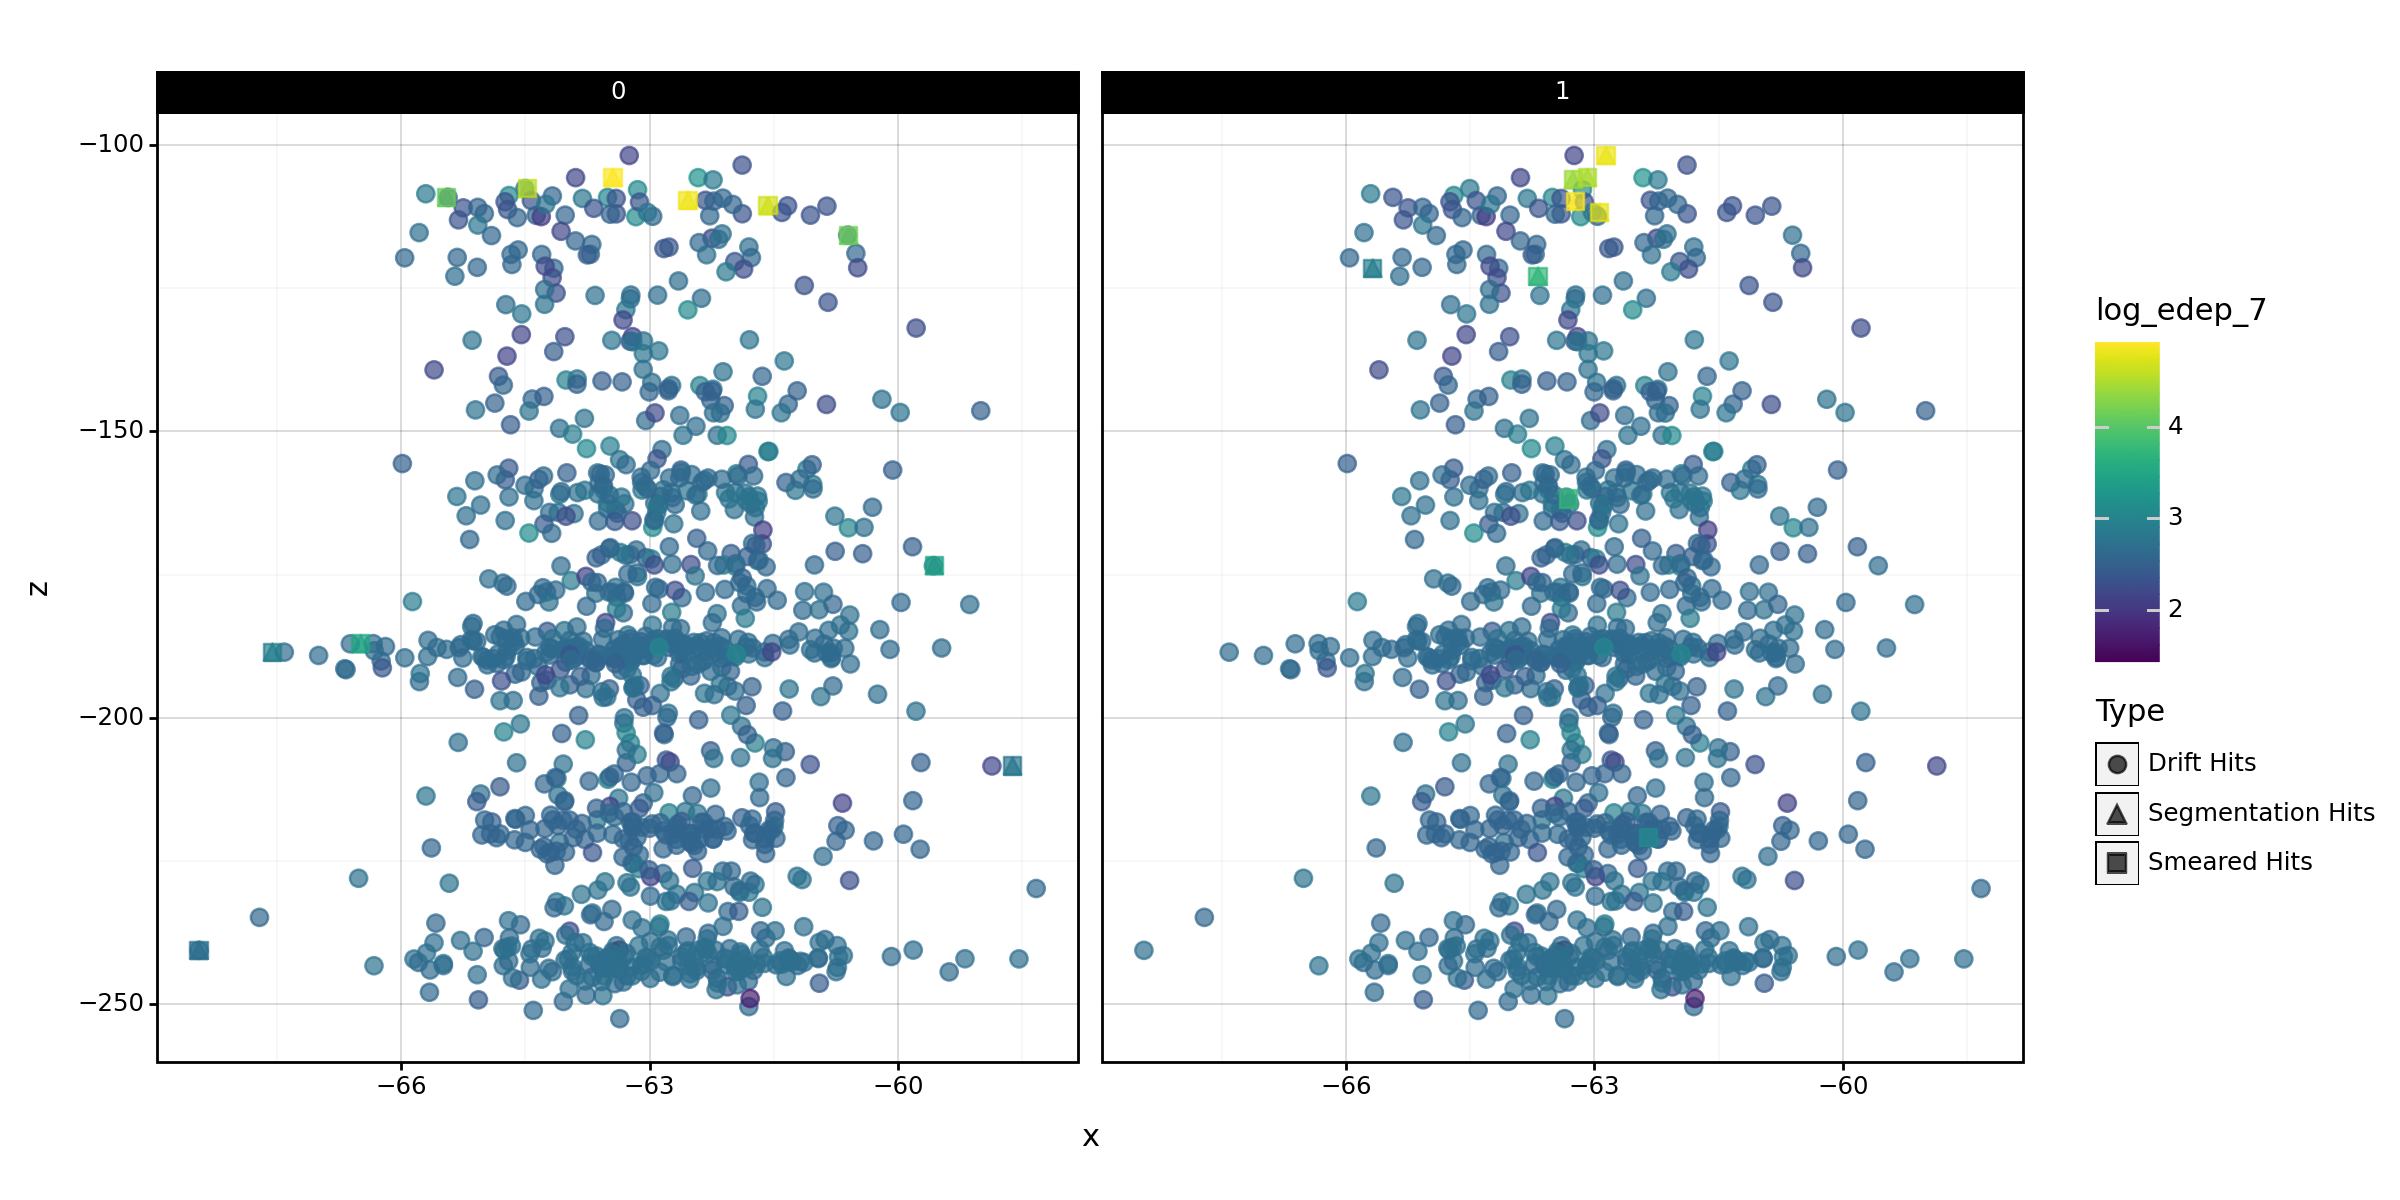

<Figure Size: (1200 x 600)>

In [11]:
from plotnine import theme, theme_linedraw, theme_set

theme_set(theme_linedraw())

(
    ggplot(df_2d, aes("x", "z", color="log_edep_7", shape="Type"))
    + geom_point(alpha=0.7, size = 3)
    + facet_wrap("~layer", scales="free_x")
    + theme(figure_size=(12, 6))
)

## Waveform Hits

Waveform hits are of RawTimeSeriesCollection. It has the following members:
- cellID: uint64_t
- time: float      
- charge:float    
- interval: float
- adcCounts: vector<int32_t>

In [12]:
wave_hits = event.get("TpcWaveformHits")

wave_cell = np.asarray(wave_hits.cellID())
wave_time = np.asarray(wave_hits.time())
wave_charge = np.asarray(wave_hits.charge())
wave_int = np.asarray(wave_hits.interval())
wave_layer = cell2layer(wave_cell)

In [13]:
def getAdcCounts(hit) -> np.ndarray:
    n = hit.adcCounts_size()
    cs = hit.getAdcCounts()
    counts = np.zeros(n, np.int32)
    for i in range(n):
        counts[i] = cs[i]
    return counts

n_hits = wave_hits.size()
temp = np.zeros(n_hits, "object")
for i in range(n_hits):
    temp[i] = getAdcCounts(wave_hits[i])
np.concatenate(temp)


array([100, 100, 100, ..., 100, 100, 100], dtype=int32)

In [14]:
from megat import getIdConverter

converter = getIdConverter()
cell2pos = np.frompyfunc(lambda id: converter.position(id), 1, 1)
wave_pos = vec3d2mat(cell2pos(wave_cell))


In [15]:
n_hits = wave_hits.size()
temp_time = np.zeros(n_hits, dtype="object")
temp_adc = np.zeros(n_hits, dtype="object")
temp_size = np.zeros(n_hits, dtype=np.int32)

for i in range(n_hits):
    _hit = wave_hits[i]
    _nadc = _hit.adcCounts_size()
    _int = wave_int[i]
    _time = wave_time[i]
    temp_size[i] = _nadc
    temp_adc[i] = getAdcCounts(_hit)
    temp_time[i] = _time + _int * np.arange(_nadc)
wave_x_all = np.repeat(wave_pos[:, 0], temp_size)
wave_y_all = np.repeat(wave_pos[:, 1], temp_size)
wave_z_all = np.repeat(wave_pos[:, 2], temp_size)
wave_layer_all = np.repeat(wave_layer, temp_size)
wave_time_all = np.concatenate(temp_time)
wave_adc_all = np.concatenate(temp_adc)



In [16]:
df_wave = tibble(
    x=wave_x_all,
    y=wave_y_all,
    z=time2z(wave_time_all, wave_z_all),
    layer=wave_layer_all,
    xy=if_else(f.layer == 0, f.x, f.y),
    adc=wave_adc_all,
    Type="Waveform Hits",
)

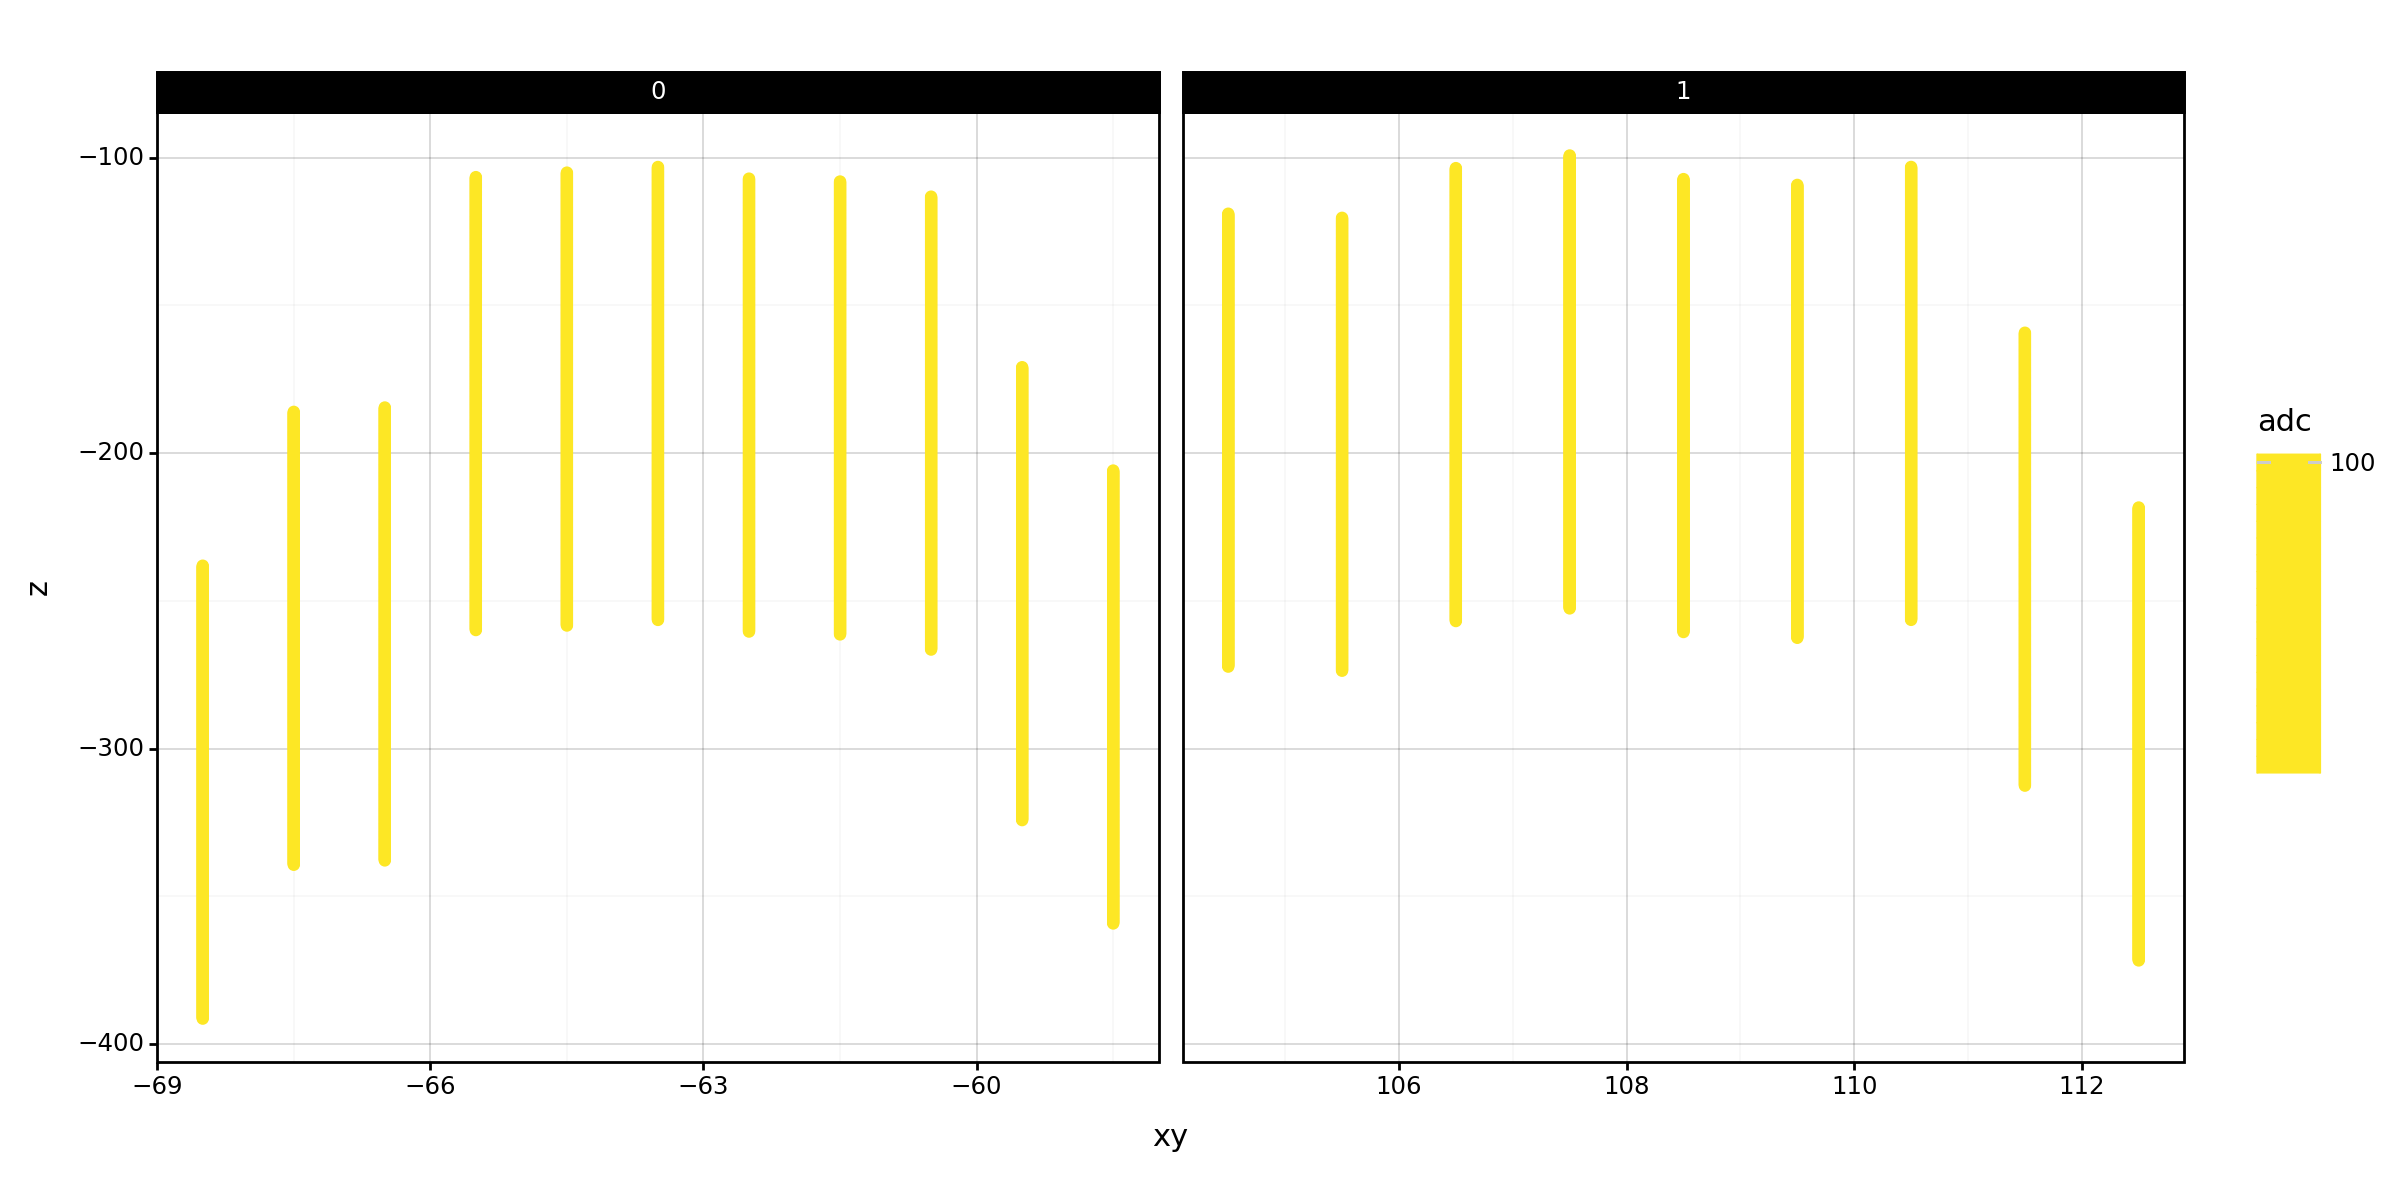

<Figure Size: (1200 x 600)>

In [17]:
(
    ggplot(df_wave, aes("xy", "z", color="adc"))
    + geom_point()
    + facet_wrap("~layer", scales="free_x")
    + theme(figure_size=(12, 6))
)

## Trajactory Hits

Tajactory hits are of SimTrackerHits.

In [18]:
traj_hits = event.get("TpcSimHits")

traj_pos = vec3d2mat(traj_hits.position())
traj_time = np.asanyarray(traj_hits.time())
traj_edep = np.asarray(traj_hits.EDep())

df_traj = tibble(
    x=traj_pos[:, 0],
    y=traj_pos[:, 1],
    z=time2z(traj_time, traj_pos[:, 2]),
    edep=traj_edep,
    edep_log_7=7+np.log10(traj_edep),
    Type="Trajactory Points"
)

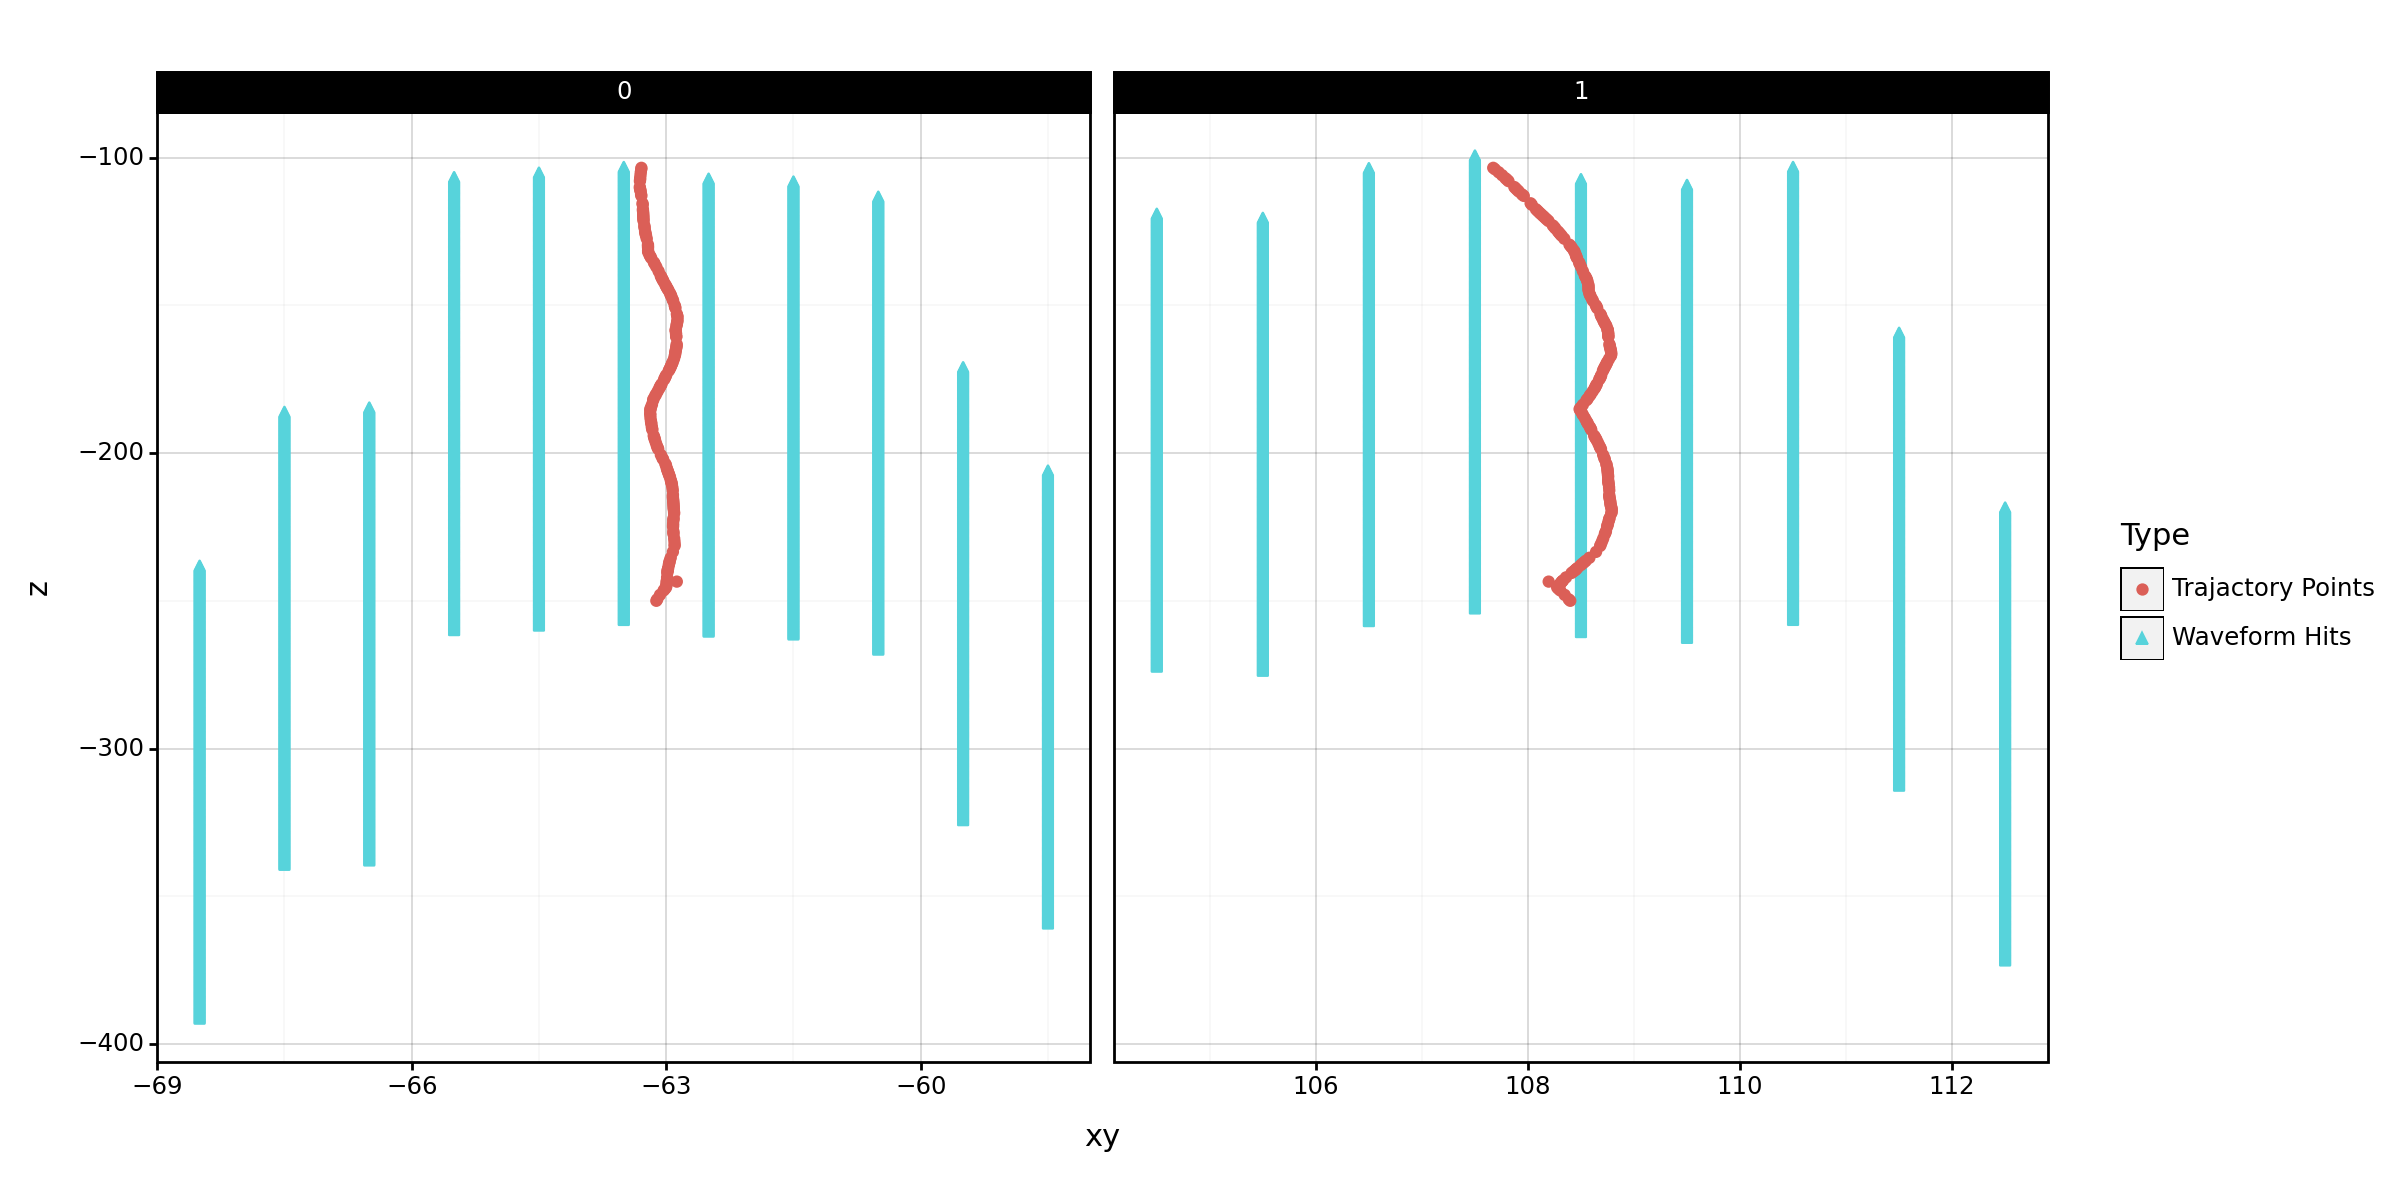

<Figure Size: (1200 x 600)>

In [19]:
(
    bind_rows(
        df_wave,
        df_traj >> mutate(layer=0, xy=f.x),  # type: ignore
        df_traj >> mutate(layer=1, xy=f.y),  # type: ignore
    )
    >> ggplot(aes("xy", "z", shape="Type", color="Type"))  # type: ignore
    + geom_point()
    + facet_wrap("~layer", scales="free_x")
    + theme(figure_size=(12, 6))
)

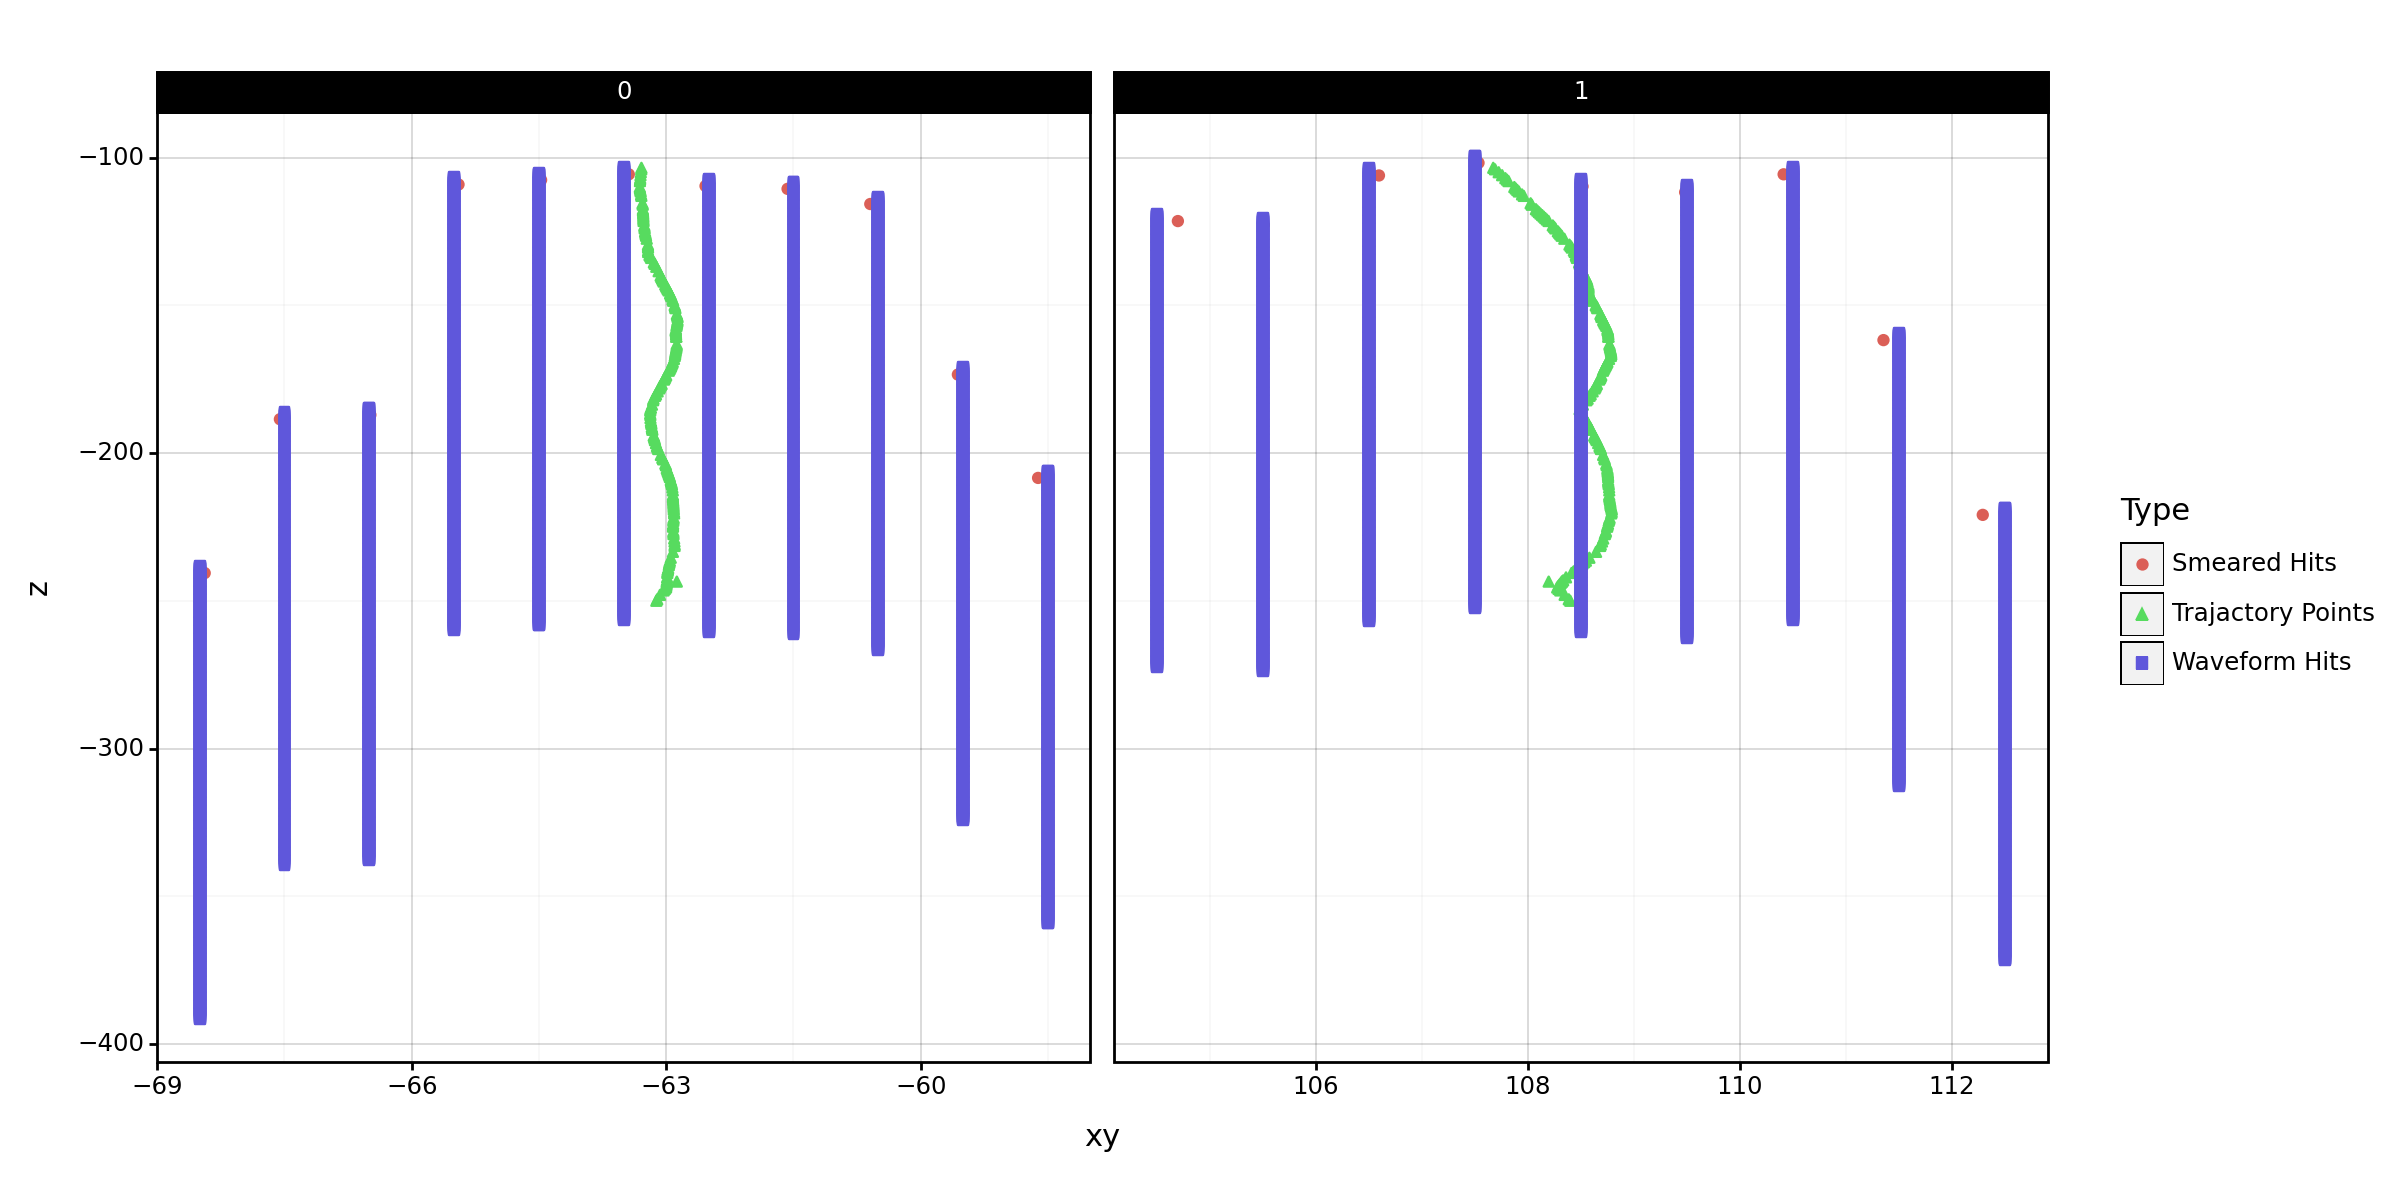

<Figure Size: (1200 x 600)>

In [20]:

(
    bind_rows(
        df_wave,
        df_traj >> mutate(layer=0, xy=f.x),  # type: ignore
        df_traj >> mutate(layer=1, xy=f.y),  # type: ignore
        df_smear >> mutate(xy=if_else(f.layer == 0, f.x, f.y)),  # type: ignore
    )
    >> ggplot(aes("xy", "z", shape="Type", color="Type"))  # type: ignore
    + geom_point()
    + facet_wrap("~layer", scales="free_x")
    + theme(figure_size=(12, 6))
)

# With new utils

In [21]:
from RecoUtils import tidyHits

event = events[42]

hits_traj = event.get("TpcSimHits")
hits_drift = event.get("TpcDriftHits")
hits_seg = event.get("TpcSegHits")
hits_smear = event.get("TpcHits")
hits_wave = event.get("TpcWaveformHits")

df_traj = tidyHits(hits_traj)
df_drift = tidyHits(hits_drift)
df_seg = tidyHits(hits_seg)
df_smear = tidyHits(hits_smear)
df_wave = tidyHits(hits_wave)

ImportError: cannot import name 'tidyHits' from 'RecoUtils' (/data/home/lixp/src/reco3d/RecoUtils.py)